### Lets see some spectograms for Data Sources

In [1]:
#loading from local
import pandas as pd

df = pd.read_parquet("/home/dilmurod/job/tts_project/data/karakalpak-speech-corpus/train-00000-of-00008.parquet")

# as it is only small part of dataset

/home/dilmurod/job/tts_project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


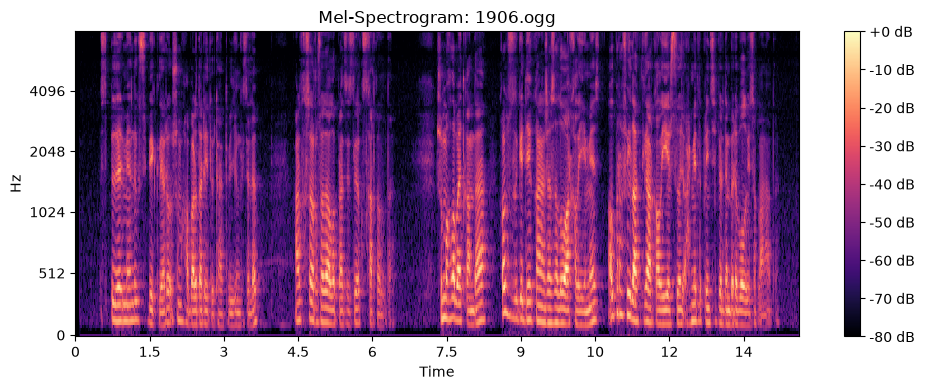

In [2]:
import io
import librosa
import librosa.display
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract the audio dictionary from a specific row (e.g., the first row)
row_index = 0
audio_dict = df.iloc[row_index]["audio"]
audio_bytes = audio_dict["bytes"]
audio_path = audio_dict.get("path", f"Sample {row_index}")

# 2. Decode the bytes into a waveform
# io.BytesIO allows soundfile to read the raw bytes directly from memory without saving to disk
with io.BytesIO(audio_bytes) as audio_file:
    y, sr = sf.read(audio_file)

# Convert to mono if the audio happens to be stereo
if len(y.shape) > 1:
    y = y.mean(axis=1)

# 3. Generate the Mel-spectrogram
# n_mels=128 is a standard resolution for TTS tasks
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)

# Convert power to decibels (log scale) so features are visible
S_dB = librosa.power_to_db(S, ref=np.max)

# 4. Plot the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel-Spectrogram: {audio_path}')
plt.tight_layout()
plt.show()

In [3]:
import io
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Select one sample
i = 0
audio = df["audio"].iloc[i]

# Decode OGG bytes
y, sr = sf.read(io.BytesIO(audio["bytes"]))

# Convert stereo -> mono if necessary
if y.ndim > 1:
    y = y.mean(axis=1)

print("Sample rate:", sr)
print("Duration:", len(y) / sr, "seconds")
print("Samples:", len(y))

Sample rate: 48000
Duration: 14.6135 seconds
Samples: 701448


/home/dilmurod/job/tts_project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


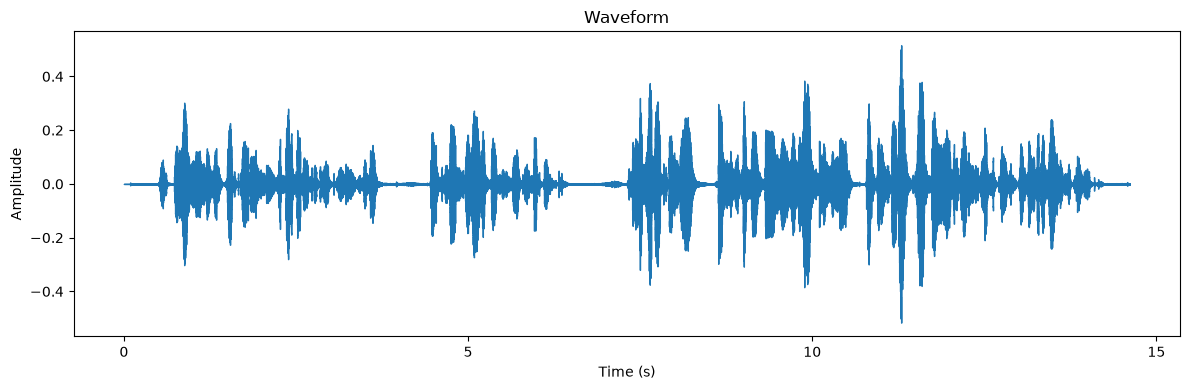

In [4]:
# waveform
plt.figure(figsize=(12, 4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

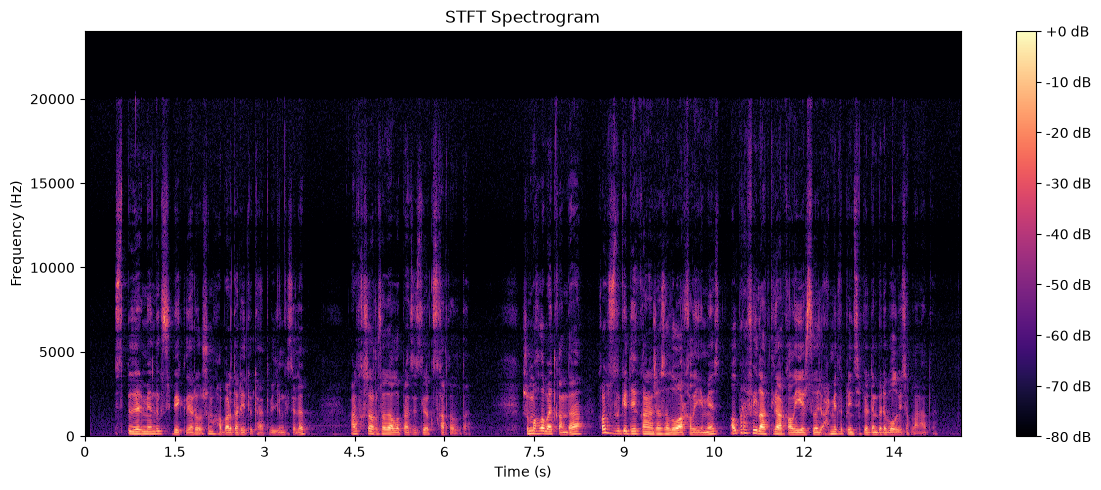

In [5]:
# STFT
n_fft = 1024
hop_length = 256

D = librosa.stft(
    y,
    n_fft=n_fft,
    hop_length=hop_length
)

# Convert amplitude to decibels
S_db = librosa.amplitude_to_db(
    np.abs(D),
    ref=np.max
)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("STFT Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

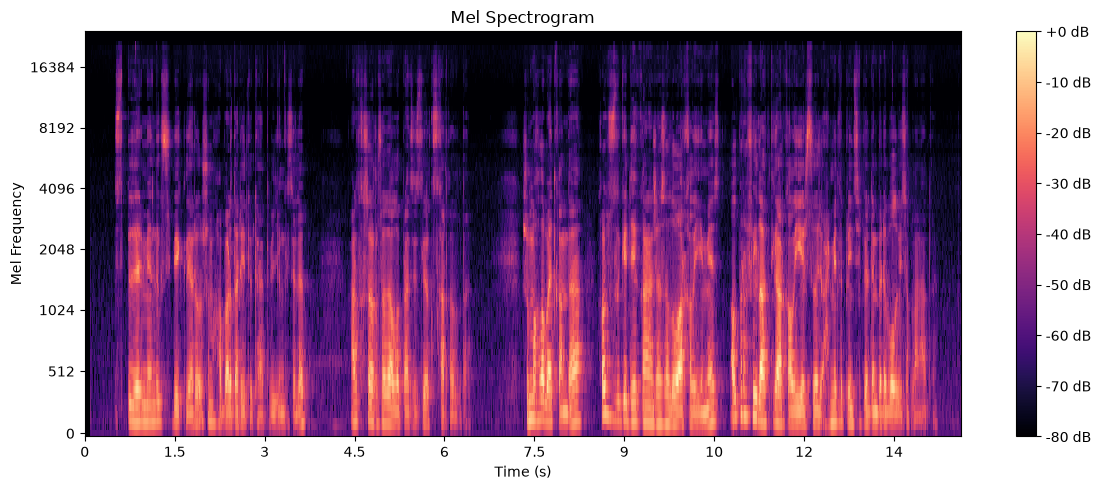

In [6]:
# Mel Spectrogram

n_mels = 80

mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Mel Frequency")
plt.tight_layout()
plt.show()

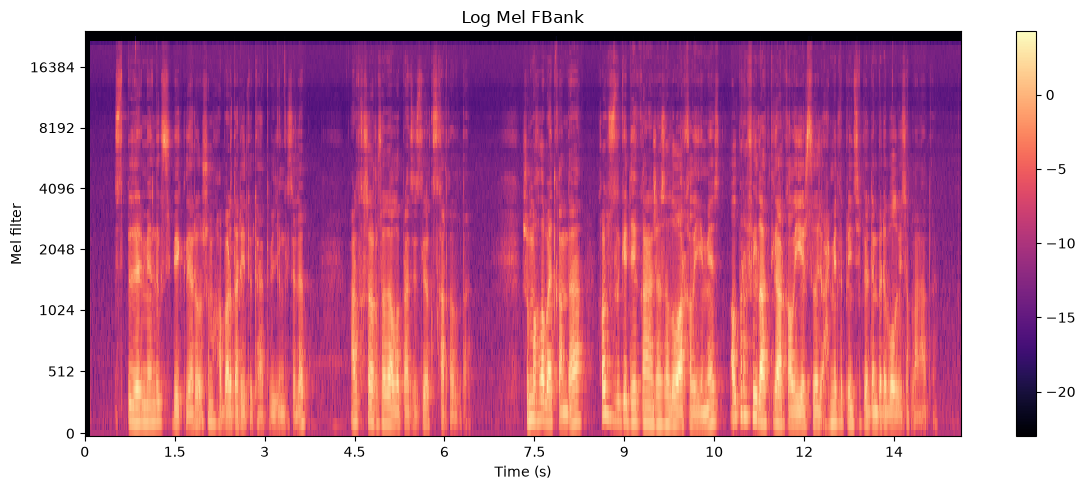

In [8]:
# fbank
# Power spectrogram
power = np.abs(D) ** 2

# Mel filter-bank energies
fbank = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=80,
    power=2.0
)

# Log-FBank
log_fbank = np.log(fbank + 1e-10)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    log_fbank,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()
plt.title("Log Mel FBank")
plt.xlabel("Time (s)")
plt.ylabel("Mel filter")
plt.tight_layout()
plt.show()

In [2]:
import io
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import librosa
import librosa.display

from IPython.display import Audio, display

# Take ONE sample
i = 0
audio = df["audio"].iloc[i]

# Decode OGG
y, sr = sf.read(io.BytesIO(audio["bytes"]))

# Stereo -> mono
if y.ndim > 1:
    y = y.mean(axis=1)

print(f"Original sample rate: {sr} Hz")
print(f"Duration: {len(y) / sr:.2f} sec")
print(f"Samples: {len(y):,}")

print("\n▶ Original audio:")
display(Audio(y, rate=sr))

Original sample rate: 48000 Hz
Duration: 14.61 sec
Samples: 701,448

▶ Original audio:
